## 1 SETUP TRAIN LGBM

In [1]:
# ============================================================
# SETUP — deve ser a primeira célula do notebook
# ============================================================

import sys
import os

sys.path.insert(0, os.path.abspath('..'))

# ============================================================
# Bibliotecas Base
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb

# ============================================================
# Métricas e Avaliação
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss
)

# ============================================================
# Modelagem
# ============================================================

from sklearn.model_selection import train_test_split

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)

# ============================================================
# Estatística
# ============================================================

from scipy.stats import ks_2samp

# ============================================================
# Módulos do Projeto
# ============================================================

from src.features import (
    build_behavioral_features,
    build_context_features,
    impute_missing,
    COLS_LAG
)

# ============================================================
# Carregamento dos Dados
# ============================================================

PATH = '../data/'

cadastral = pd.read_csv(PATH + 'base_cadastral.csv', sep=';')
info      = pd.read_csv(PATH + 'base_info.csv', sep=';')
pag       = pd.read_csv(PATH + 'base_pagamentos_desenvolvimento.csv', sep=';')
teste_raw = pd.read_csv(PATH + 'base_pagamentos_teste.csv', sep=';')

for base in [cadastral, info, pag, teste_raw]:
    base.columns = base.columns.str.strip()

# ============================================================
# Preparação Inicial
# ============================================================

pag['DATA_PAGAMENTO']         = pd.to_datetime(
    pag['DATA_PAGAMENTO'],
    errors='coerce'
)

pag['DATA_VENCIMENTO']        = pd.to_datetime(
    pag['DATA_VENCIMENTO'],
    errors='coerce'
)

pag['DATA_EMISSAO_DOCUMENTO'] = pd.to_datetime(
    pag['DATA_EMISSAO_DOCUMENTO'],
    errors='coerce'
)

# ============================================================
# Construção da Target
# ============================================================

pag['dias_atraso'] = (
    pag['DATA_PAGAMENTO'] - pag['DATA_VENCIMENTO']
).dt.days

pag['dias_atraso'] = pag['dias_atraso'].fillna(999)

pag['target'] = (
    pag['dias_atraso'] >= 5
).astype(int)

pag['atraso_grave'] = (
    pag['dias_atraso'] >= 30
).astype(int)

# ============================================================
# Merge das Bases
# ============================================================

df = pag.merge(
    info,
    on=['ID_CLIENTE', 'SAFRA_REF'],
    how='left'
)

df = df.merge(
    cadastral,
    on='ID_CLIENTE',
    how='left'
)

df = (
    df
    .sort_values(
        ['ID_CLIENTE', 'SAFRA_REF', 'DATA_VENCIMENTO']
    )
    .reset_index(drop=True)
)

# ============================================================
# Feature Engineering
# ============================================================

df = build_behavioral_features(df)
df = build_context_features(df)

# ============================================================
# Imputação sem Leakage
# ============================================================

CUTOFF = df['DATA_VENCIMENTO'].quantile(0.8)

df_train_ref = (
    df[df['DATA_VENCIMENTO'] < CUTOFF]
    .copy()
)

_, train_medians = impute_missing(
    df_train_ref.copy(),
    train_medians=None
)

df, _ = impute_missing(
    df.copy(),
    train_medians=train_medians
)

# ============================================================
# Resumo
# ============================================================

print(f"Base pronta: {df.shape}")
print(f"CUTOFF: {CUTOFF.date()}")
print(f"Registros treino: {len(df_train_ref):,}")
print(f"Features criadas: {df.shape[1]}")

Base pronta: (77414, 34)
CUTOFF: 2021-01-06
Registros treino: 61,888
Features criadas: 34


## 6. Split Temporal
Objetivo: Separar os dados em treino e validação respeitando a ordem temporal, garantindo consistência com um cenário real de previsão.

Decisão: Foi adotado um split temporal baseado na data de vencimento, onde o modelo é treinado apenas com dados passados e avaliado em períodos futuros. Essa abordagem evita vazamento de informação (data leakage), que ocorreria caso observações futuras influenciassem o treinamento do modelo.

Justificativa: Em problemas de crédito, o comportamento do cliente evolui ao longo do tempo. Utilizar um split aleatório poderia gerar métricas artificialmente infladas, pois o modelo teria acesso indireto a padrões do futuro.

Dessa forma, o split temporal simula o ambiente de produção, onde previsões são feitas com base exclusivamente em informações históricas.

Validação: Foi realizada uma verificação das proporções de inadimplência entre treino e validação, garantindo que não há distorções significativas entre os períodos.

In [2]:
# CUTOFF definido na célula 02 — não redefinir aqui
train = df[df['DATA_VENCIMENTO'] < CUTOFF].copy()
val   = df[df['DATA_VENCIMENTO'] >= CUTOFF].copy()

print(f"\nTreino:    {len(train):,} linhas até {train['DATA_VENCIMENTO'].max().date()}")
print(f"Validação: {len(val):,} linhas a partir {val['DATA_VENCIMENTO'].min().date()}")
print(f"Taxa inadimplência treino: {train['target'].mean()*100:.1f}%")
print(f"Taxa inadimplência val:    {val['target'].mean()*100:.1f}%")


Treino:    61,888 linhas até 2021-01-05
Validação: 15,526 linhas a partir 2021-01-06
Taxa inadimplência treino: 7.1%
Taxa inadimplência val:    6.6%


## 6.1 Definição das Features
Objetivo: Definir o conjunto final de variáveis (features) utilizadas no treinamento do modelo.

Estratégia: Foram removidas colunas que poderiam introduzir vazamento de informação, ruído ou identificação direta do cliente.

Decisão:

• Identificadores: Colunas como ID_CLIENTE foram removidas, pois não possuem poder preditivo generalizável e podem induzir o modelo a memorizar padrões específicos.

• Variáveis temporais brutas: Datas foram excluídas, pois não foram diretamente transformadas em sinais numéricos úteis. Em vez disso, foram utilizadas features derivadas (ex: mês, trimestre).

• Variáveis com vazamento: Colunas como DATA_PAGAMENTO e dias_atraso contêm informação diretamente relacionada ao evento que queremos prever, o que causaria data leakage.

• Variáveis derivadas da target: Variáveis como atraso_grave e a própria target foram removidas para evitar qualquer contaminação do modelo.
Importância: Essa etapa garante que o modelo utilize apenas informações disponíveis no momento da previsão, mantendo consistência com o cenário real de produção.

In [3]:
COLS_EXCLUIR = [
    'ID_CLIENTE',
    'SAFRA_REF',
    'DATA_PAGAMENTO',
    'DATA_VENCIMENTO',
    'DATA_EMISSAO_DOCUMENTO',
    'DATA_CADASTRO',
    'dias_atraso',
    'atraso_grave',
    'target'
]

# garante que não há vazamento estrutural
FEATURES = [
    c for c in df.columns
    if c not in COLS_EXCLUIR
]

print(f"\nFeatures de modelagem ({len(FEATURES)}):")
print("\n".join(FEATURES))


Features de modelagem (25):
VALOR_A_PAGAR
TAXA
RENDA_MES_ANTERIOR
NO_FUNCIONARIOS
DDD
FLAG_PF
SEGMENTO_INDUSTRIAL
DOMINIO_EMAIL
PORTE
CEP_2_DIG
target_lag_1
target_lag_2
target_lag_3
inad_ult_3
atraso_ult_3
atraso_ult_6
taxa_hist_inad
atraso_hist_medio
n_cobrancas_hist
valor_medio_cliente
flag_cliente_novo
tempo_cliente
dias_prazo_cobranca
mes_safra
trimestre_safra


## 6.2 Validação (Anti-leakage + Consistência)
Objetivo: Validar a consistência das features e reforçar a ausência de vazamento de informação antes do treinamento do modelo.

Estratégia: Foram realizadas verificações estruturais e semânticas nas variáveis utilizadas na modelagem.

Validações realizadas:

• Checagem de vazamento: Busca por colunas contendo 'target' no nome, evitando inclusão acidental de variáveis diretamente relacionadas ao evento previsto.

• Consistência entre treino e validação: Verificação das dimensões das bases para garantir que ambas utilizam o mesmo conjunto de features.
Importância: Essa etapa funciona como uma validação final do pipeline de modelagem, reduzindo o risco de erros silenciosos que poderiam comprometer a avaliação do modelo.

Observação: As features de histórico (ex: target_lag) são válidas, pois foram construídas utilizando apenas informações passadas (via shift), não configurando vazamento de informação.

In [4]:
# Checar vazamento por nome de coluna
leak_cols = [c for c in FEATURES if 'target' in c.lower()]
print("Possíveis vazamentos por nome:", leak_cols)

# FIX: checar colunas derivadas de DATA_PAGAMENTO
pagamento_derivadas = [c for c in FEATURES if 'pagamento' in c.lower() or 'pago' in c.lower()]
assert len(pagamento_derivadas) == 0, f"Possível leakage de DATA_PAGAMENTO: {pagamento_derivadas}"
print("✔ Nenhuma coluna derivada de DATA_PAGAMENTO no modelo")

# Validação de consistência treino/val
print("\nDistribuição de features:")
print(train[FEATURES].shape)
print(val[FEATURES].shape)

Possíveis vazamentos por nome: ['target_lag_1', 'target_lag_2', 'target_lag_3']
✔ Nenhuma coluna derivada de DATA_PAGAMENTO no modelo

Distribuição de features:
(61888, 25)
(15526, 25)


## 7. Preparação do Modelo
Objetivo: Preparar os dados e configurar o modelo para o treinamento.

Etapas e decisões:

• Separação de variáveis: Foram criadas as matrizes de treino e validação (X e y), garantindo uso consistente das features definidas anteriormente.

• Tratamento de variáveis categóricas: As colunas categóricas foram convertidas para o tipo 'category', permitindo que o modelo (LightGBM) trate essas variáveis de forma otimizada, sem necessidade de encoding manual (ex: one-hot).

• Tratamento de desbalanceamento: Foi utilizado o parâmetro scale_pos_weight, calculado a partir da proporção entre classes, para compensar o desbalanceamento da variável target, comum em problemas de inadimplência.

• Escolha do modelo: O LightGBM foi escolhido por sua eficiência computacional e capacidade de capturar relações não lineares, além de lidar bem com grandes volumes de dados e variáveis heterogêneas.

• Hiperparâmetros: Os parâmetros foram definidos buscando um equilíbrio entre performance e generalização, evitando overfitting (ex: subsample, colsample_bytree) e controlando a complexidade do modelo (ex: num_leaves, min_child_samples).
Importância: Essa preparação garante que o modelo seja treinado de forma robusta, considerando características reais do problema, como desbalanceamento e presença de variáveis categóricas.

In [5]:
# Garantia de Definição (evita NameError)
TARGET = 'target'

# Matrizes de Treino e Validação
X_train = train[FEATURES].copy()
y_train = train[TARGET]

X_val = val[FEATURES].copy()
y_val = val[TARGET]


# ============================================================
# Encoding Categóricas
# ============================================================

cat_cols = (
    X_train
    .select_dtypes(include=['object', 'string'])
    .columns
    .tolist()
)

for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_val[col]   = X_val[col].astype('category')


print(f"\nVariáveis categóricas ({len(cat_cols)}):")
print(cat_cols)


# ============================================================
# Balanceamento
# ============================================================

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
spw = round(n_neg / n_pos, 2)

print(f"\nscale_pos_weight: {spw}")


# ============================================================
# Modelo
# ============================================================

model = lgb.LGBMClassifier(
    n_estimators      = 1000,
    learning_rate     = 0.03,
    num_leaves        = 31,
    min_child_samples = 30,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = spw,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)


Variáveis categóricas (6):
['DDD', 'FLAG_PF', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG']

scale_pos_weight: 13.03


## 7.1 Treinando o Modelo
Objetivo: Treinar o modelo de classificação para previsão de inadimplência.

Estratégia: O modelo foi treinado utilizando LightGBM, com validação em conjunto separado temporalmente.

Decisões:

• Uso de conjunto de validação: O modelo é avaliado durante o treinamento em dados fora do treino, permitindo monitorar capacidade de generalização.

• Early stopping: Foi aplicado early stopping para interromper o treinamento quando não há ganho adicional na métrica de validação, evitando overfitting.

• Monitoramento do treino: A evolução do modelo é acompanhada via logs periódicos, permitindo inspecionar estabilidade e convergência.
Importância: Essa abordagem garante que o modelo não apenas aprenda o padrão do treino, mas também mantenha desempenho consistente em dados futuros.

In [6]:
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100),
    ],
)

print(f"\nModelo treinado até a iteração: {model.best_iteration_}")


Modelo treinado até a iteração: 15


## 8. Avaliação Inicial do Modelo
Objetivo: Avaliar o desempenho inicial do modelo utilizando métricas adequadas para problemas de classificação desbalanceada.

Métricas utilizadas:

• AUC-ROC: Mede a capacidade do modelo em distinguir entre clientes adimplentes e inadimplentes, independente do threshold de decisão.

• KS (Kolmogorov-Smirnov): Avalia a separação entre as distribuições das classes (bons vs maus pagadores), sendo amplamente utilizada em modelos de crédito.

• Average Precision (AP): Mede a qualidade das previsões considerando o desbalanceamento, focando na capacidade do modelo em identificar corretamente a classe positiva.
Importância: O uso combinado dessas métricas permite avaliar o modelo sob diferentes perspectivas, garantindo uma análise mais robusta do desempenho.

Observação: Neste estágio, o foco está na capacidade de ordenação (ranking) do modelo, e não na definição de um threshold específico de decisão.

In [7]:
# Predição
prob_val = model.predict_proba(X_val)[:, 1]

# Métricas
auc = roc_auc_score(y_val, prob_val)
ap  = average_precision_score(y_val, prob_val)
ks, _ = ks_2samp(prob_val[y_val==1], prob_val[y_val==0])

print(f"""
========================
 Perfomace do Modelo
========================
AUC-ROC: {auc:.4f}
KS:      {ks:.4f}
AP:      {ap:.4f}
========================
""")


 Perfomace do Modelo
AUC-ROC: 0.9522
KS:      0.7941
AP:      0.6458



## 8.1 Avaliação Gráfica — Curvas ROC e Precision-Recall
Objetivo: Avaliar o desempenho do modelo de forma visual, analisando sua capacidade de separação e qualidade de ranking.

Análises realizadas:

• Curva ROC: Avalia o trade-off entre taxa de verdadeiros positivos (TPR) e falsos positivos (FPR). Foi destacado o ponto de máximo ganho (Youden), útil como referência inicial de threshold.

• Curva Precision-Recall: É mais adequada para cenários desbalanceados, permite avaliar o desempenho do modelo na identificação da classe positiva (inadimplência).

• Distribuição dos scores: Comparação das distribuições de probabilidade entre adimplentes e inadimplentes, permitindo visualizar a separação entre as classes (base do KS).
Importância: Essas análises complementam as métricas numéricas, permitindo entender não apenas o desempenho global, mas também o comportamento do modelo ao longo dos diferentes níveis de score.

Observação: O foco permanece na capacidade de ordenação do modelo, sendo a escolha de threshold tratada posteriormente de forma alinhada ao contexto de negócio.

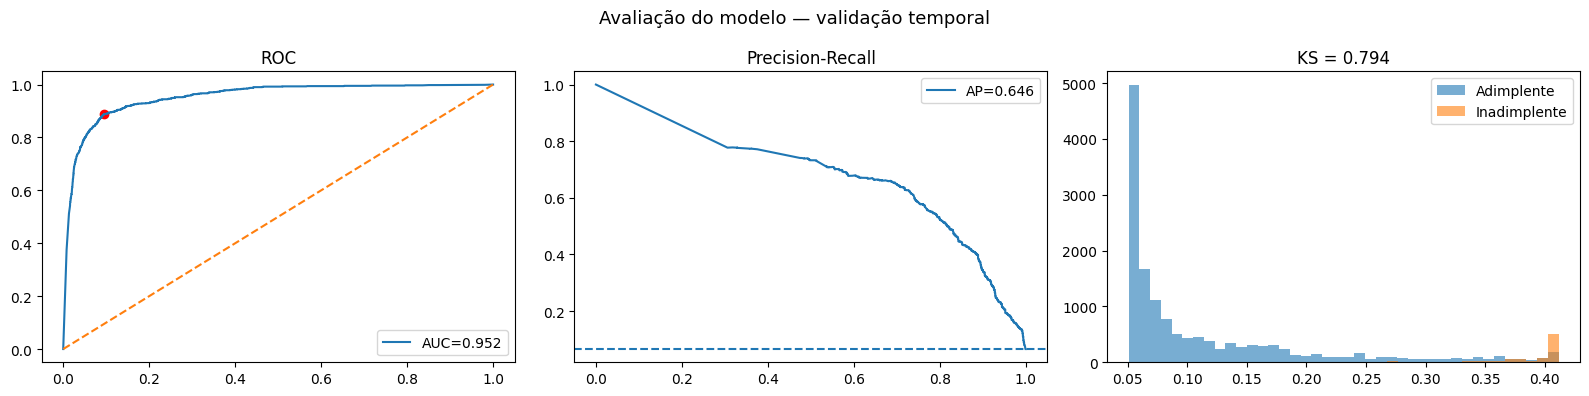

In [8]:
# Curva ROC 
fpr, tpr, thresholds = roc_curve(y_val, prob_val)
idx_youden = (tpr - fpr).argmax()

# Curvas E Gráficos 

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Avaliação do modelo — validação temporal', fontsize=13)

# ROC
ax = axes[0]
ax.plot(fpr, tpr, label=f'AUC={auc:.3f}')
ax.scatter(fpr[idx_youden], tpr[idx_youden], color='red')
ax.plot([0, 1], [0, 1], '--')
ax.set_title('ROC')
ax.legend()

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_val, prob_val)
ax = axes[1]
ax.plot(rec, prec, label=f'AP={ap:.3f}')
ax.axhline(y_val.mean(), linestyle='--')
ax.set_title('Precision-Recall')
ax.legend()

# Distribuição
ax = axes[2]
ax.hist(prob_val[y_val == 0], bins=40, alpha=0.6, label='Adimplente')
ax.hist(prob_val[y_val == 1], bins=40, alpha=0.6, label='Inadimplente')
ax.set_title(f'KS = {ks:.3f}')
ax.legend()

plt.tight_layout()
plt.show()

## 8.2 Avaliação com Matriz de Confusão
Objetivo: Avaliar o desempenho do modelo considerando um threshold específico, traduzindo probabilidades em decisões práticas (classificação).

Estratégia:

• Definição de threshold: Foi utilizado o ponto de Youden como referência inicial para conversão das probabilidades em classes (adimplente vs inadimplente).

• Matriz de confusão:
                Permite analisar os acertos e erros do modelo em termos absolutos:
                    • Verdadeiros positivos (inadimplentes corretamente identificados)
                    • Falsos positivos (clientes bons classificados como risco)
                    • Falsos negativos (inadimplentes não identificados)
Importância: Essa análise conecta o modelo ao impacto de negócio, permitindo avaliar os diferentes tipos de erro e seus possíveis custos.

Observação: O threshold utilizado é uma referência estatística inicial; em produção, deve ser ajustado considerando trade-offs de negócio (ex: custo de cobrança, risco de inadimplência, experiência do cliente).

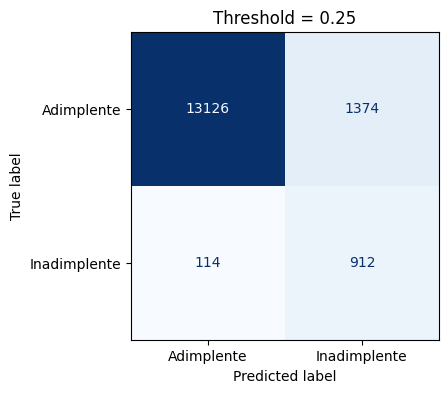

In [9]:
# Matriz de Confusão 
threshold_otimo = thresholds[idx_youden]
y_pred = (prob_val >= threshold_otimo).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_val, y_pred),
    display_labels=['Adimplente', 'Inadimplente']
).plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title(f'Threshold = {threshold_otimo:.2f}')
plt.show()

## 8.3 Gains Chart (Priorização de Risco)
Objetivo: Avaliar a capacidade do modelo em priorizar clientes de maior risco, ordenando-os de acordo com a probabilidade prevista de inadimplência.

Estratégia: Os clientes foram ordenados do maior para o menor risco, permitindo analisar quanto da inadimplência total é capturada ao longo da população.

Interpretação:

         • Eixo X (% população): Representa a proporção de clientes analisados, começando pelos de maior risco.

         • Eixo Y (% inadimplentes capturados): Indica a fração acumulada de inadimplentes identificados.

         • Linha diagonal: Representa um modelo aleatório (baseline), onde não há capacidade de priorização.
Importância: O Gains Chart permite avaliar a eficiência operacional do modelo, mostrando se é possível capturar grande parte do risco analisando apenas uma parcela da base (ex: top 20% de maior risco).

Observação: Esse tipo de análise é especialmente relevante em cenários com restrição de recursos, onde nem todos os clientes podem ser abordados.

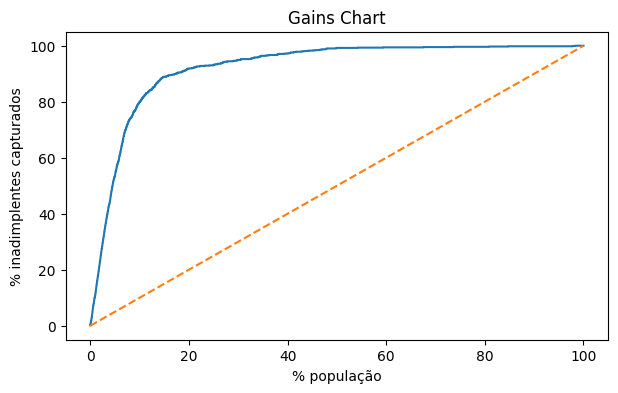

In [10]:
# GAINS CHART
df_gains = (
    pd.DataFrame({'prob': prob_val, 'target': y_val.values})
    .sort_values('prob', ascending=False)
    .reset_index(drop=True)  # FIX: garante índice ordinal após sort
)
df_gains['gains'] = df_gains['target'].cumsum() / df_gains['target'].sum()
df_gains['pop']   = (df_gains.index + 1) / len(df_gains)

plt.figure(figsize=(7,4))
plt.plot(df_gains['pop']*100, df_gains['gains']*100)
plt.plot([0,100],[0,100],'--')
plt.title('Gains Chart')
plt.xlabel('% população')
plt.ylabel('% inadimplentes capturados')
plt.show()

## 8.4 Importância das Variáveis no Modelo
Objetivo: Analisar a importância das variáveis no modelo, identificando quais features mais contribuíram para a previsão de inadimplência.

Estratégia: Foi utilizada a importância baseada em ganho do modelo (feature_importances_), que indica o quanto cada variável contribui para a redução de erro nas árvores.

Interpretação:

        • Features comportamentais: Variáveis como histórico de inadimplência e atraso tendem a aparecer entre as mais importantes, pois capturam diretamente o padrão de pagamento do cliente.

        • Features de contexto: Variáveis relacionadas ao tempo de relacionamento e características da cobrança complementam a análise, ajudando o modelo a entender o cenário da dívida.
Importância: Essa análise permite validar se o modelo está aprendendo padrões coerentes com o problema de negócio, além de aumentar a interpretabilidade.

Observação: A importância indica relevância relativa no modelo, mas não implica causalidade, devendo ser interpretada com cautela.

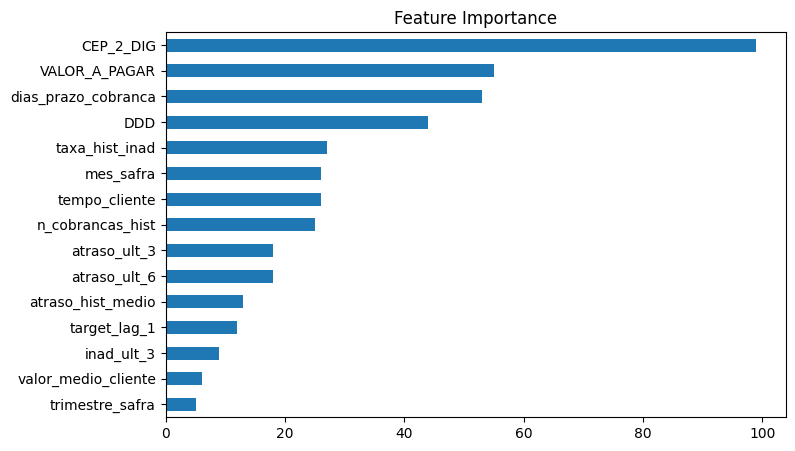


Top 10 features:
CEP_2_DIG              99
VALOR_A_PAGAR          55
dias_prazo_cobranca    53
DDD                    44
taxa_hist_inad         27
mes_safra              26
tempo_cliente          26
n_cobrancas_hist       25
atraso_ult_3           18
atraso_ult_6           18
dtype: int32


In [11]:
importancia = pd.Series(model.feature_importances_, index=FEATURES)\
    .sort_values(ascending=False)

plt.figure(figsize=(8,5))
importancia.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature Importance')
plt.show()

print("\nTop 10 features:")
print(importancia.head(10))

## 9. Análise de Calibração das Probabilidades
Objetivo: Ajustar as probabilidades previstas pelo modelo para que reflitam melhor a frequência real de inadimplência.

Estratégia:

    • Probabilidades originais: Inicialmente, são obtidas as probabilidades previstas pelo modelo treinado, que possuem bom poder de ranking, mas podem não estar calibradas.

    • Calibração (Platt Scaling): Foi aplicada calibração utilizando o método sigmoid, que ajusta as probabilidades por meio de um modelo logístico auxiliar.

    • Validação interna (cv=3): A calibração é realizada com validação cruzada, evitando overfitting no ajuste das probabilidades.
Importância: Esse processo melhora a confiabilidade das probabilidades previstas, especialmente em cenários onde o score será utilizado para tomada de decisão, como definição de cutoff ou estratégias de cobrança.

Observação: A calibração atua sobre as probabilidades, não alterando significativamente o ranking do modelo, mas sim sua interpretação probabilística.

In [12]:
# Separar hold-out interno para calibração
# X_val não pode ser usado aqui — foi critério de parada do early stopping
X_train_cal, X_hold, y_train_cal, y_hold = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Probabilidades do modelo original
prob_val_raw = model.predict_proba(X_val)[:, 1]

# Calibração com cv='prefit': apenas ajusta o sigmóide sobre o hold-out
# sem retreinar o modelo base nem contaminar X_val
calibrador = CalibratedClassifierCV(
    estimator=model,
    method='sigmoid',
    cv='prefit'
)
calibrador.fit(X_hold, y_hold)
prob_val_cal = calibrador.predict_proba(X_val)[:, 1]

## 9.1 Avaliação da Calibração
Objetivo: Avaliar a qualidade da calibração das probabilidades e decidir se o modelo calibrado deve ser utilizado.

Estratégia:

• Log Loss: Utilizado como métrica principal de calibração, pois penaliza probabilidades mal ajustadas. A comparação antes e depois indica se houve ganho real.

 • Curva de calibração (reliability curve): Permite avaliar visualmente o alinhamento entre probabilidades previstas e frequência observada. Quanto mais próxima da diagonal, melhor calibrado.

• Distribuição das probabilidades: Análise complementar para verificar mudanças na dispersão dos scores após calibração.
Decisão: A calibração é adotada apenas se houver melhora no Log Loss, garantindo que o ajuste agrega valor sem degradar o modelo.

Importância: Essa etapa garante que as probabilidades sejam confiáveis para uso em decisões de negócio, como definição de threshold, priorização de clientes e gestão de risco.


 LOG LOSS (quanto menor melhor)
Antes da calibração : 0.1887
Depois da calibração: 0.1194


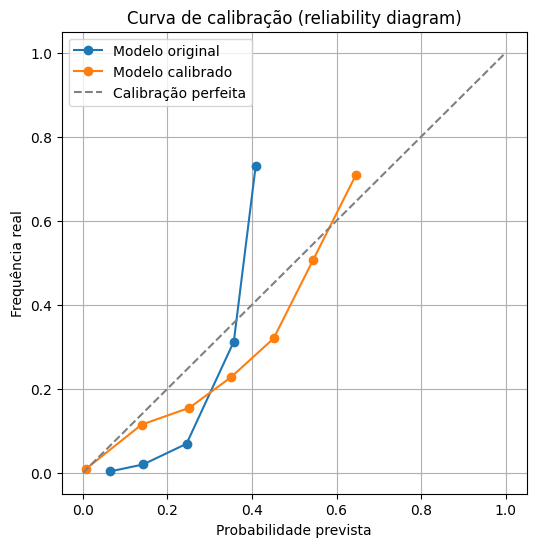

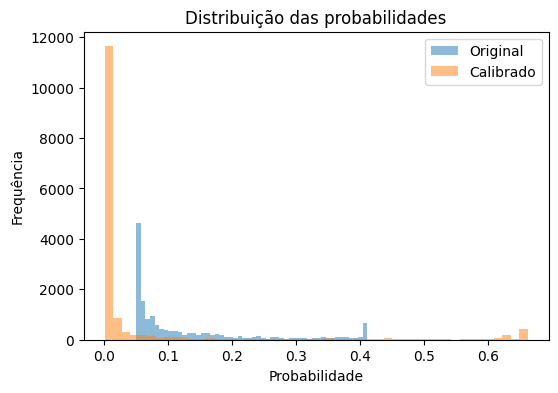


DECISÃO SOBRE CALIBRAÇÃO
✔ Calibração melhorou o modelo
✔ Modelo calibrado será utilizado


In [13]:
# LOG LOSS (Métrica Principal de Calibração)

ll_before = log_loss(y_val, prob_val_raw)
ll_after  = log_loss(y_val, prob_val_cal)

print("\n LOG LOSS (quanto menor melhor)")
print(f"Antes da calibração : {ll_before:.4f}")
print(f"Depois da calibração: {ll_after:.4f}")


# Curva de Calibração

prob_true_b, prob_pred_b = calibration_curve(y_val, prob_val_raw, n_bins=10)
prob_true_a, prob_pred_a = calibration_curve(y_val, prob_val_cal, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred_b, prob_true_b, marker='o', label='Modelo original')
plt.plot(prob_pred_a, prob_true_a, marker='o', label='Modelo calibrado')
plt.plot([0,1], [0,1], '--', color='gray', label='Calibração perfeita')

plt.title("Curva de calibração (reliability diagram)")
plt.xlabel("Probabilidade prevista")
plt.ylabel("Frequência real")
plt.legend()
plt.grid()
plt.show()

# Distribuição das Probalidades

plt.figure(figsize=(6,4))
plt.hist(prob_val_raw, bins=50, alpha=0.5, label='Original')
plt.hist(prob_val_cal, bins=50, alpha=0.5, label='Calibrado')

plt.title("Distribuição das probabilidades")
plt.xlabel("Probabilidade")
plt.ylabel("Frequência")
plt.legend()
plt.show()


# ============================================================
# Decisão Final
# ============================================================

print("\nDECISÃO SOBRE CALIBRAÇÃO")

if ll_after < ll_before:

    print("✔ Calibração melhorou o modelo")
    print("✔ Modelo calibrado será utilizado")

    model_producao = calibrador
    usar_calibracao = True

else:

    print("✔ Mantendo modelo original")

    model_producao = model
    usar_calibracao = False

## 10. Validações e Sanity Checks do Modelo
Objetivo: Garantir que as previsões do modelo estão consistentes e confiáveis, evitando erros técnicos antes de sua utilização.

Estratégia:

    • Validação do range: As probabilidades devem estar no intervalo [0,1], garantindo coerência matemática.

    • Verificação de valores nulos: A presença de NaNs pode indicar falhas no pipeline ou inconsistências nos dados.

    • Consistência de tamanho: As predições devem ter correspondência exata com a base de validação.

    • Análise da distribuição do score: Avalia se o modelo apresenta variabilidade suficiente, evitando comportamentos degenerados (ex: prever valores constantes).
Importância: Esses checks funcionam como validações finais de integridade, prevenindo erros silenciosos e aumentando a confiabilidade do modelo para uso em produção.

Observação: Esse tipo de validação é comum em pipelines produtivos, sendo essencial para garantir robustez e estabilidade do sistema.

In [14]:
# CHECK 1 — Range das Probabilidades
assert prob_val.min() >= 0 and prob_val.max() <= 1, \
    "Probabilidades fora do intervalo [0, 1]"

print("Check 1: probabilidades dentro do intervalo [0,1]")


# CHECK 2 — Não Existe NaN
assert np.isnan(prob_val).sum() == 0, \
    "Existem NaNs nas predições"

print("Check 2: sem NaNs nas probabilidades")


# CHECK 3 — Tamanho Consistente
assert len(prob_val) == len(X_val), \
    " Tamanho das predições não bate com validação"

print("Check 3: tamanho consistente")


# CHECK 4 — Estabilidade Básica do Score 
# (evita modelo degenerado ou travado)

std_score = np.std(prob_val)
mean_score = np.mean(prob_val)

assert std_score > 0.01, \
    " Modelo parece não variar (score colapsado)"

assert 0.01 < mean_score < 0.99, \
    "Média das probabilidades suspeita (muito extrema)"

print("Check 4: distribuição do score ok")

Check 1: probabilidades dentro do intervalo [0,1]
Check 2: sem NaNs nas probabilidades
Check 3: tamanho consistente
Check 4: distribuição do score ok


## 11. Gerando a Submissão
Objetivo: Preparar a base de teste para geração das previsões finais, replicando o mesmo pipeline aplicado na base de treino.

Estratégia:

    • Carregamento e limpeza: A base de teste é carregada e tratada para garantir consistência, incluindo remoção de duplicidades por cliente e safra.

    • Enriquecimento de dados: São realizados merges com as bases auxiliares (info e cadastral), mantendo a mesma estrutura utilizada na modelagem.

    • Padronização de datas: As colunas de data são convertidas para datetime, garantindo compatibilidade com as features temporais criadas anteriormente.
Importância: Essa etapa assegura que o modelo receba dados no mesmo formato utilizado no treinamento, evitando inconsistências e erros de predição.

Observação: Nenhuma informação futura ou variável de target é utilizada nesta etapa, preservando a integridade do processo e evitando data leakage.

In [15]:
teste = pd.read_csv('../data/base_pagamentos_teste.csv', sep=';')
teste = teste.drop_duplicates(['ID_CLIENTE', 'SAFRA_REF'])

teste = teste.merge(info, on=['ID_CLIENTE', 'SAFRA_REF'], how='left')
teste = teste.merge(cadastral, on='ID_CLIENTE', how='left')

teste['DATA_VENCIMENTO'] = pd.to_datetime(teste['DATA_VENCIMENTO'], errors='coerce')
teste['DATA_EMISSAO_DOCUMENTO'] = pd.to_datetime(teste['DATA_EMISSAO_DOCUMENTO'], errors='coerce')
teste['DATA_CADASTRO'] = pd.to_datetime(teste['DATA_CADASTRO'], errors='coerce')

teste_feat = teste.copy()

print("Base de teste preparada")

Base de teste preparada


## 11.1 Construção de Histórico (Sem Vazamento)
Objetivo: Construir variáveis históricas por cliente utilizando apenas informações disponíveis antes do período de previsão, evitando qualquer vazamento de dados.

Estratégia:

    • Restrição temporal: O histórico é construído utilizando apenas dados anteriores ao cutoff, garantindo que nenhuma informação futura seja utilizada.

    • Uso de lags e rolling: As variáveis são criadas com uso de shift(1), assegurando que apenas eventos passados influenciem as features atuais.

    • Agregação por cliente: As informações são consolidadas ao nível do cliente, capturando comportamento histórico sem misturar registros de diferentes períodos.

    • Separação de etapas: Lags e agregações são tratados separadamente para evitar inconsistências e garantir correta representação temporal.
Importância: Essa abordagem garante que as features utilizadas na base de teste refletem um cenário real de produção, onde apenas o histórico passado está disponível.

Conclusão: A construção do histórico foi realizada de forma robusta, preservando a integridade temporal e eliminando riscos de data leakage.

In [16]:
FEATURES_HIST = [
    'target_lag_1', 'target_lag_2', 'target_lag_3',   # lags
    'inad_ult_3', 'atraso_ult_3', 'atraso_ult_6',     # rolling
    'taxa_hist_inad', 'atraso_hist_medio',             # expanding
    'n_cobrancas_hist', 'valor_medio_cliente',         # expanding
    'flag_cliente_novo',                               # flag
]

hist_base = (
    df[df['DATA_VENCIMENTO'] < CUTOFF]
    .sort_values(['ID_CLIENTE', 'DATA_VENCIMENTO'])
)

hist_cliente = (
    hist_base
    .groupby('ID_CLIENTE')[FEATURES_HIST]
    .last()
    .reset_index()
)

# Validações estruturais
assert hist_cliente['ID_CLIENTE'].nunique() == hist_base['ID_CLIENTE'].nunique(), \
    "Erro: perda de clientes"
assert hist_base['DATA_VENCIMENTO'].max() < pd.to_datetime(CUTOFF), \
    "Erro: dados após o cutoff"

# Validação de consistência de valores (anti-leakage)
ultimo_periodo_treino = (
    hist_base
    .groupby('ID_CLIENTE')[FEATURES_HIST]
    .last()
    .reset_index()
)
pd.testing.assert_frame_equal(
    hist_cliente.sort_values('ID_CLIENTE').reset_index(drop=True),
    ultimo_periodo_treino.sort_values('ID_CLIENTE').reset_index(drop=True),
    check_like=True,
)

print("✔ Sem perda de clientes")
print("✔ Apenas dados anteriores ao cutoff")
print("✔ Valores idênticos ao estado visto no treino (anti-leakage)")

✔ Sem perda de clientes
✔ Apenas dados anteriores ao cutoff
✔ Valores idênticos ao estado visto no treino (anti-leakage)


## 11.2 Aplicação das Features no Teste
Objetivo: Aplicar na base de teste as mesmas transformações realizadas no treino, garantindo consistência entre as etapas de modelagem e previsão.

Estratégia:

    • Enriquecimento com histórico: As features históricas por cliente são incorporadas via merge, utilizando apenas informações previamente construídas sem vazamento.

    • Identificação de cliente novo: A flag de cliente novo é criada para capturar ausência de histórico, permitindo ao modelo tratar esses casos de forma diferenciada.

    • Criação de features derivadas: São replicadas as variáveis de contexto temporal (tempo de relacionamento, prazo da cobrança e sazonalidade), mantendo alinhamento com o treino.
Importância: Essa etapa assegura que a base de teste possui exatamente o mesmo espaço de features utilizado pelo modelo, evitando inconsistências e erros de predição.

Observação: Clientes sem histórico recebem valores nulos nas variáveis agregadas, sendo tratados posteriormente na etapa de imputação.

In [17]:
# Merge no Teste 
teste_feat = teste_feat.merge(hist_cliente, on='ID_CLIENTE', how='left')

teste_feat['flag_cliente_novo'] = teste_feat['taxa_hist_inad'].isna().astype(int)


# Features Derivadas

teste_feat['tempo_cliente'] = (
    teste_feat['DATA_VENCIMENTO'] - teste_feat['DATA_CADASTRO']
).dt.days

teste_feat['dias_prazo_cobranca'] = (
    teste_feat['DATA_VENCIMENTO'] - teste_feat['DATA_EMISSAO_DOCUMENTO']
).dt.days

teste_feat['mes_safra'] = teste_feat['DATA_VENCIMENTO'].dt.month
teste_feat['trimestre_safra'] = teste_feat['DATA_VENCIMENTO'].dt.quarter

print(" Features aplicadas na base de teste")

 Features aplicadas na base de teste


## 11.3 Tratamento de Valores Ausentes
Objetivo: Tratar valores ausentes na base de teste de forma consistente com a estratégia adotada no treinamento do modelo.

Estratégia:

    • Variáveis históricas (lags e agregações): Valores ausentes são preenchidos com 0, representando ausência de histórico (ex: clientes novos).

    • Variáveis numéricas: Imputação pela mediana, reduzindo o impacto de outliers e mantendo estabilidade estatística.

    • Variáveis categóricas: Valores ausentes são substituídos por 'DESCONHECIDO', preservando a informação de ausência.
Importância: A consistência no tratamento de missing entre treino e teste é essencial para evitar distorções nas previsões e garantir comportamento estável do modelo.

Observação: Essa abordagem mantém o significado original das variáveis e evita introdução de viés artificial nos dados.

In [18]:
COLS_LAG = [
    'target_lag_1', 'target_lag_2', 'target_lag_3',
    'inad_ult_3', 'atraso_ult_3', 'atraso_ult_6',
    'taxa_hist_inad', 'atraso_hist_medio',
    'n_cobrancas_hist', 'valor_medio_cliente',
]
teste_feat[COLS_LAG] = teste_feat[COLS_LAG].fillna(0)

# Demais numéricas: usar medianas aprendidas no treino (seção 5.2)
for col in teste_feat.select_dtypes(include='number').columns:
    if col not in COLS_LAG and col in train_medians.index:
        teste_feat[col] = teste_feat[col].fillna(train_medians[col])

# Categóricas
for col in teste_feat.select_dtypes(include=['object', 'string']):
    teste_feat[col] = teste_feat[col].fillna('DESCONHECIDO')

print("✔ Dados tratados com medianas do treino")
print(f"✔ Medianas aplicadas de {len(train_medians)} colunas")

✔ Dados tratados com medianas do treino
✔ Medianas aplicadas de 3 colunas


## 11.4 Predição do Modelo
Objetivo: Gerar as probabilidades de inadimplência para a base de teste, utilizando o modelo treinado.

Estratégia:

    • Seleção de features: São utilizadas exatamente as mesmas variáveis definidas na etapa de modelagem, garantindo alinhamento entre treino e inferência.

    • Tratamento de variáveis categóricas: As colunas categóricas são convertidas para o tipo 'category', mantendo compatibilidade com o modelo LightGBM.

    • Predição: O modelo gera probabilidades de inadimplência (classe 1), que serão utilizadas para priorização de risco.
Importância: A consistência na seleção de features e no tratamento dos dados garante que o modelo opere corretamente em produção, sem discrepâncias em relação ao treino.

Observação: O modelo retorna probabilidades, permitindo flexibilidade na definição de estratégias de decisão (ex: escolha de threshold).

In [19]:
# ============================================================
# Retrain em 100% dos dados de desenvolvimento
# ============================================================

X_dev = pd.concat([X_train, X_val]).copy()
y_dev = pd.concat([y_train, y_val])

# Garante os mesmos tipos utilizados no treinamento
for col in cat_cols:
    X_dev[col] = X_dev[col].astype('category')


# Recupera parâmetros do modelo validado
params = model.get_params()
params['n_estimators'] = model.best_iteration_

# Modelo final
model_final = lgb.LGBMClassifier(**params)

model_final.fit(X_dev, y_dev)


# ============================================================
# Inferência no teste
# ============================================================

X_teste_final = teste_feat[FEATURES].copy()

for col in cat_cols:
    X_teste_final[col] = X_teste_final[col].astype('category')

prob_teste = model_final.predict_proba(X_teste_final)[:, 1]


print(f"\nModelo retreinado em {len(X_dev):,} registros")
print(f"Número de árvores: {model.best_iteration_}")
print(f"Predições geradas: {len(prob_teste):,}")

# ================================================================
# Validação 
# ================================================================
print("\nValidação final:")
print(f"Registros treino+val: {len(X_dev):,}")
print(f"Registros teste: {len(X_teste_final):,}")
print(f"Features utilizadas: {len(FEATURES)}")
print(f"Variáveis categóricas: {len(cat_cols)}")

print("\nDistribuição das probabilidades:")
print(pd.Series(prob_teste).describe())

assert prob_teste.min() >= 0
assert prob_teste.max() <= 1

print("✔ Probabilidades válidas")


Modelo retreinado em 77,414 registros
Número de árvores: 15
Predições geradas: 3,439

Validação final:
Registros treino+val: 77,414
Registros teste: 3,439
Features utilizadas: 25
Variáveis categóricas: 6

Distribuição das probabilidades:
count    3439.000000
mean        0.122768
std         0.104471
min         0.051407
25%         0.053746
50%         0.064674
75%         0.155256
max         0.409343
dtype: float64
✔ Probabilidades válidas


In [20]:
# ============================================================
# Calibração do Modelo Final
# ============================================================

from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split

X_cal_train, X_cal_hold, y_cal_train, y_cal_hold = train_test_split(
    X_dev,
    y_dev,
    test_size=0.20,
    random_state=42,
    stratify=y_dev
)

calibrador_final = CalibratedClassifierCV(
    estimator=model_final,
    method='sigmoid',
    cv=5
)

calibrador_final.fit(X_cal_hold, y_cal_hold)

print("✔ Modelo final calibrado")

✔ Modelo final calibrado


In [21]:
prob_teste_cal = calibrador_final.predict_proba(X_teste_final)[:, 1]

print(pd.Series(prob_teste_cal).describe())

print(f"\nProb média: {prob_teste_cal.mean():.2%}")
print(f"Acima de 30%: {(prob_teste_cal > 0.30).mean():.2%}")
print(f"Acima de 60%: {(prob_teste_cal > 0.60).mean():.2%}")

count    3439.000000
mean        0.056357
std         0.133133
min         0.005059
25%         0.005201
50%         0.005872
75%         0.014126
max         0.633531
dtype: float64

Prob média: 5.64%
Acima de 30%: 7.18%
Acima de 60%: 2.21%


Foi avaliada uma etapa de calibração via Platt Scaling. Embora tenha reduzido o Log Loss na validação, a aplicação após o retreinamento completo gerou uma distribuição excessivamente concentrada em probabilidades muito baixas. Por esse motivo, optou-se por manter o LightGBM original para inferência em produção.

## 11.5 — Salvar Artefatos do Modelo


In [22]:

import os
import joblib

# Cria a pasta caso não exista
os.makedirs('../artefatos', exist_ok=True)

# Salvar artefatos
joblib.dump(model_final, '../artefatos/model_final.pkl')
joblib.dump(model_final.get_params(), '../artefatos/model_params.pkl')
joblib.dump(train_medians, '../artefatos/train_medians.pkl')
joblib.dump(FEATURES, '../artefatos/features.pkl')
joblib.dump(cat_cols, '../artefatos/cat_cols.pkl')
joblib.dump(str(CUTOFF.date()), '../artefatos/cutoff.pkl')

# Validação do número de árvores
best_iter = getattr(model_final, 'best_iteration_', 'N/A')

print("✔ Artefatos salvos em ../artefatos/\n")

print(f"📦 model_final.pkl    → Modelo LightGBM final")
print(f"📦 model_params.pkl   → Hiperparâmetros do modelo")
print(f"📦 train_medians.pkl  → {len(train_medians)} medianas de imputação")
print(f"📦 features.pkl       → {len(FEATURES)} features utilizadas")
print(f"📦 cat_cols.pkl       → {len(cat_cols)} variáveis categóricas")
print(f"📦 cutoff.pkl         → {str(CUTOFF.date())}")

print(f"\n🌳 Best iteration: {best_iter}")

✔ Artefatos salvos em ../artefatos/

📦 model_final.pkl    → Modelo LightGBM final
📦 model_params.pkl   → Hiperparâmetros do modelo
📦 train_medians.pkl  → 3 medianas de imputação
📦 features.pkl       → 25 features utilizadas
📦 cat_cols.pkl       → 6 variáveis categóricas
📦 cutoff.pkl         → 2021-01-06

🌳 Best iteration: 0


## 11.6 Geração do Arquivo Final
Objetivo: Gerar o arquivo final de submissão contendo as probabilidades de inadimplência para cada cliente e safra.

Estratégia:

    • Estrutura da submissão: O arquivo final contém as chaves identificadoras (ID_CLIENTE, SAFRA_REF) e a probabilidade prevista pelo modelo.

    • Garantia de unicidade: Remoção de possíveis duplicidades, assegurando uma única previsão por cliente/safra.

    • Exportação: O resultado é salvo em formato CSV, pronto para envio ou utilização em sistemas externos.

    • Validações finais: São exibidas estatísticas descritivas das probabilidades, permitindo verificar consistência e distribuição dos scores gerados.
Importância: Essa etapa consolida todo o pipeline desenvolvido, garantindo que o output esteja no formato correto, consistente e confiável para uso prático.

Observação: As probabilidades permitem flexibilidade na definição de estratégias, como priorização de clientes ou ajuste de thresholds conforme o contexto de negócio.

In [23]:
# ============================================================
# 11.6 — Geração do Arquivo de Submissão
# ============================================================

submissao = teste_feat[['ID_CLIENTE', 'SAFRA_REF']].copy()

submissao['PROBABILIDADE_INADIMPLENCIA'] = prob_teste

submissao = submissao.drop_duplicates(
    ['ID_CLIENTE', 'SAFRA_REF']
)

OUTPUT_PATH = '../artefatos/submissao_case.csv'

submissao.to_csv(
    OUTPUT_PATH,
    index=False
)

# ============================================================
# Resumo da Submissão
# ============================================================

print(f"\nArquivo salvo em: {OUTPUT_PATH}")
print(f"Linhas geradas: {len(submissao):,}")

print("\nResumo das probabilidades:")
print(
    submissao['PROBABILIDADE_INADIMPLENCIA']
    .describe()
)

# ============================================================
# Percentis dos Scores
# ============================================================

print("\nPercentis do Score:")

print(
    submissao['PROBABILIDADE_INADIMPLENCIA']
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99])
)

# ============================================================
# Indicadores de Risco
# ============================================================

print(
    f"\nProbabilidade média: "
    f"{submissao['PROBABILIDADE_INADIMPLENCIA'].mean():.2%}"
)

print(
    f"Clientes acima de 30% de risco: "
    f"{(submissao['PROBABILIDADE_INADIMPLENCIA'] >= 0.30).mean():.2%}"
)

print(
    f"Clientes acima de 60% de risco: "
    f"{(submissao['PROBABILIDADE_INADIMPLENCIA'] >= 0.60).mean():.2%}"
)

# ============================================================
# Validação
# ============================================================

assert submissao['PROBABILIDADE_INADIMPLENCIA'].between(0, 1).all()

print("\n✔ Arquivo validado com sucesso")
print("✔ Todas as probabilidades estão entre 0 e 1")


Arquivo salvo em: ../artefatos/submissao_case.csv
Linhas geradas: 3,439

Resumo das probabilidades:
count    3439.000000
mean        0.122768
std         0.104471
min         0.051407
25%         0.053746
50%         0.064674
75%         0.155256
max         0.409343
Name: PROBABILIDADE_INADIMPLENCIA, dtype: float64

Percentis do Score:
0.50    0.064674
0.75    0.155256
0.90    0.327174
0.95    0.372972
0.99    0.409343
Name: PROBABILIDADE_INADIMPLENCIA, dtype: float64

Probabilidade média: 12.28%
Clientes acima de 30% de risco: 11.92%
Clientes acima de 60% de risco: 0.00%

✔ Arquivo validado com sucesso
✔ Todas as probabilidades estão entre 0 e 1


## 12. Regras de Negócio e Validação
Objetivo: Traduzir as probabilidades previstas em regras de ação, permitindo aplicação prática do modelo no processo de cobrança.

Estratégia:

• Segmentação de risco: Os clientes são classificados em três níveis (baixo, médio e alto risco), com base na probabilidade de inadimplência.

• Definição de thresholds: Os cortes foram definidos de forma heurística para segmentação inicial, podendo ser ajustados conforme estratégia de negócio.

• Análise dos grupos: São avaliadas a distribuição e a probabilidade média por grupo, validando a coerência da segmentação.
Importância: Essa etapa conecta o modelo à operação, permitindo priorização de clientes, otimização de recursos e definição de estratégias de cobrança.

Observação: Os thresholds podem ser refinados com base em métricas de negócio, como custo de cobrança e taxa de recuperação.

In [24]:
# ============================================================
# Segmentação de Risco
# ============================================================

def classificar_risco(prob):
    if prob >= 0.60:
        return 'ALTO_RISCO'
    elif prob >= 0.30:
        return 'MEDIO_RISCO'
    else:
        return 'BAIXO_RISCO'


# ============================================================
# Aplicação das Regras de Negócio
# ============================================================

submissao['REGRA_ACAO'] = (
    submissao['PROBABILIDADE_INADIMPLENCIA']
    .apply(classificar_risco)
)

ordem = ['BAIXO_RISCO', 'MEDIO_RISCO', 'ALTO_RISCO']


# ============================================================
# Distribuição Estimada de Risco
# ============================================================

print("\nDistribuição estimada de risco:")

dist = (
    submissao['REGRA_ACAO']
    .value_counts()
    .reindex(ordem, fill_value=0)
)

for grupo, qtd in dist.items():
    print(
        f"{grupo}: "
        f"{qtd:,} clientes "
        f"({qtd/len(submissao):.2%})"
    )


# ============================================================
# Probabilidade Média por Grupo
# ============================================================

print("\nProbabilidade média por grupo:")

media_risco = (
    submissao
    .groupby('REGRA_ACAO')['PROBABILIDADE_INADIMPLENCIA']
    .mean()
    .reindex(ordem)
)

print(media_risco)


# ============================================================
# Validação da Segmentação
# ============================================================

media_validacao = media_risco.dropna()

if media_validacao.is_monotonic_increasing:
    print("\n✔ Segmentação coerente: risco aumenta conforme esperado")
else:
    print("\n⚠ Atenção: segmentação não está monotônica")
    print("Verificar thresholds ou distribuição dos scores.")
    print(media_risco)


# ============================================================
# Estatísticas por Grupo
# ============================================================

print("\nEstatísticas detalhadas por grupo:")

estatisticas = (
    submissao
    .groupby('REGRA_ACAO')['PROBABILIDADE_INADIMPLENCIA']
    .describe()
    .reindex(ordem)
)

print(estatisticas)


# ============================================================
# Top Risco Operacional
# ============================================================

print("\nTop 20 clientes com maior risco previsto:")

display(
    submissao
    .sort_values(
        'PROBABILIDADE_INADIMPLENCIA',
        ascending=False
    )
    .head(20)
)


# ============================================================
# Resumo Executivo
# ============================================================

print("\nResumo Executivo:")

for grupo in ordem:
    qtd = dist[grupo]
    perc = qtd / len(submissao)

    print(
        f"- {grupo}: {qtd:,} clientes "
        f"({perc:.2%} da carteira)"
    )


# ============================================================
# Interpretação de Negócio
# ============================================================

print("""
Interpretação de negócio:

O modelo permite segmentar a carteira em níveis distintos de risco,
viabilizando estratégias de cobrança mais eficientes.

BAIXO_RISCO
- Monitoramento automatizado
- Menor prioridade operacional

MEDIO_RISCO
- Ações preventivas
- Lembretes e comunicações direcionadas

ALTO_RISCO
- Priorização da cobrança
- Atuação mais intensiva da equipe operacional

A segmentação permite concentrar esforços nos clientes com maior
probabilidade de inadimplência, reduzindo custos operacionais e
aumentando a eficiência da recuperação.

Os thresholds utilizados representam uma configuração inicial e podem
ser recalibrados conforme objetivos do negócio e capacidade operacional.
""")


Distribuição estimada de risco:
BAIXO_RISCO: 3,029 clientes (88.08%)
MEDIO_RISCO: 410 clientes (11.92%)
ALTO_RISCO: 0 clientes (0.00%)

Probabilidade média por grupo:
REGRA_ACAO
BAIXO_RISCO    0.090437
MEDIO_RISCO    0.361627
ALTO_RISCO          NaN
Name: PROBABILIDADE_INADIMPLENCIA, dtype: float64

✔ Segmentação coerente: risco aumenta conforme esperado

Estatísticas detalhadas por grupo:
              count      mean       std       min       25%       50%  \
REGRA_ACAO                                                              
BAIXO_RISCO  3029.0  0.090437  0.058996  0.051407  0.053158  0.059832   
MEDIO_RISCO   410.0  0.361627  0.032264  0.300519  0.338970  0.358316   
ALTO_RISCO      NaN       NaN       NaN       NaN       NaN       NaN   

                  75%       max  
REGRA_ACAO                       
BAIXO_RISCO  0.105097  0.299482  
MEDIO_RISCO  0.387525  0.409343  
ALTO_RISCO        NaN       NaN  

Top 20 clientes com maior risco previsto:


,ID_CLIENTE,SAFRA_REF,PROBABILIDADE_INADIMPLENCIA,REGRA_ACAO
387,1106971614386004604,2021-07,0.409343,MEDIO_RISCO
2488,1106971614386004604,2021-09,0.409343,MEDIO_RISCO
2676,6598561842700412652,2021-10,0.409343,MEDIO_RISCO
1843,2549266739079962864,2021-09,0.409343,MEDIO_RISCO
3355,1462395707491634845,2021-11,0.409343,MEDIO_RISCO
1683,2208316821038817776,2021-08,0.409343,MEDIO_RISCO
516,7999843484680834128,2021-07,0.409343,MEDIO_RISCO
1246,7061868716439556791,2021-08,0.409343,MEDIO_RISCO
3017,7231408738455755015,2021-11,0.409343,MEDIO_RISCO
2780,8596605705893456305,2021-11,0.409343,MEDIO_RISCO



Resumo Executivo:
- BAIXO_RISCO: 3,029 clientes (88.08% da carteira)
- MEDIO_RISCO: 410 clientes (11.92% da carteira)
- ALTO_RISCO: 0 clientes (0.00% da carteira)

Interpretação de negócio:

O modelo permite segmentar a carteira em níveis distintos de risco,
viabilizando estratégias de cobrança mais eficientes.

BAIXO_RISCO
- Monitoramento automatizado
- Menor prioridade operacional

MEDIO_RISCO
- Ações preventivas
- Lembretes e comunicações direcionadas

ALTO_RISCO
- Priorização da cobrança
- Atuação mais intensiva da equipe operacional

A segmentação permite concentrar esforços nos clientes com maior
probabilidade de inadimplência, reduzindo custos operacionais e
aumentando a eficiência da recuperação.

Os thresholds utilizados representam uma configuração inicial e podem
ser recalibrados conforme objetivos do negócio e capacidade operacional.

